# CMI with $S$

Calculating CMI with density matrices 

\begin{equation}

CMI = I(A:C|B) = S(AB) + S(BC) - S(ABC) - S(B),

\end{equation}

where $S(Q)$ is the von Neumann entropy of the $Q$ subsystem:

\begin{equation}

S(Q) = - tr ( \rho_{Q} \log \rho_Q ),

\end{equation}

with

\begin{equation}

\rho_{Q} = tr_{\bar{Q}} (\rho).

\end{equation}

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import math
from functools import reduce

We will start from defining the GHZ state:

\begin{equation}

\ket{\text{GHZ}}= \frac{1}{\sqrt{2}}(\ket{0}^{\otimes N}+ \ket{1}^{\otimes N})

\end{equation}

and the density matrix:

\begin{equation}

\rho_0 = \ket{\text{GHZ}} \bra{\text{GHZ}}

\end{equation}

In [5]:
#Defining rho_0

# -------------------------
# Tensor product helper
# -------------------------
def kron_power(v, N):
    """Compute v ⊗ v ⊗ ... ⊗ v (N times)"""
    return reduce(np.kron, [v] * N)

# -------------------------
# Parameters
# -------------------------
N = 12  # number of qubits

# -------------------------
# Basis states |0> and |1>
# -------------------------
ket_0 = np.array([1, 0])
ket_1 = np.array([0, 1])

# -------------------------
# Build product states
# |0...0> and |1...1>
# -------------------------
ket_0N = kron_power(ket_0, N)
ket_1N = kron_power(ket_1, N)

# -------------------------
# GHZ state
# -------------------------
ket_GHZ = (ket_0N + ket_1N) / np.sqrt(2)

print("GHZ state shape:", ket_GHZ.shape)

# -------------------------
# Density matrix
# -------------------------
rho_GHZ = np.outer(ket_GHZ, ket_GHZ.conj())
print(rho_GHZ)
print("Density matrix shape:", rho_GHZ.shape)


GHZ state shape: (4096,)
[[0.5 0.  0.  ... 0.  0.  0.5]
 [0.  0.  0.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]
 ...
 [0.  0.  0.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]
 [0.5 0.  0.  ... 0.  0.  0.5]]
Density matrix shape: (4096, 4096)


Subsequantly, we define the noise channel:

\begin{equation}

\mathcal{E}^i_p(\cdot) = (1-p)(\cdot) + pX_i(\cdot)X_i

\end{equation}

acting on every qubit.

In [6]:
#Defining the noise channel

#defining Pauli X matrix 

Pauli_X= np.array([[0, 1],[1, 0]])
print(Pauli_X)

#defining identity matrix 

I = np.eye(2)


#Defining local operator
def local_operator(op, i, N):
    """
    Build operator acting on i-th qubit (0-based index) in N-qubit system.
    """
    ops = [I] * N
    ops[i] = op
    return reduce(np.kron, ops)

#Defining the noise channel
def bit_flip_channel(rho, p, i, N):
    """ 
    Function implementing the application of the noise channel on qubit i. 
    Returns the matrix rho_p_i after the application of the noise on one qubit
    i - qubit number
    p - noise rate 
    N - total system size
    rho - total density matrix
    """
    X_i = local_operator(Pauli_X, i, N)
    return (1 - p) * rho + p * (X_i @ rho @ X_i)



[[0 1]
 [1 0]]


In [7]:
#Test 

# apply channel on qubit 0
p_test = 0.1
rho_out = bit_flip_channel(rho_GHZ, p_test, i=0, N=N)

print(rho_out)

[[0.45 0.   0.   ... 0.   0.   0.45]
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.45 0.   0.   ... 0.   0.   0.45]]


In [8]:
#Repeated application of bit flip chanell

def noise_channel(rho_0, p, N):
    """ 
    Function implementing the noise channel on qubit all qubits. 
    Returns the matrix rho_p_i after the application of the noise on one qubit
    i - qubit number
    p - noise rate 
    N - total system size
    rho_0 - initial density matrix
    """
    rho = rho_0
    for i in range(N):
        rho = bit_flip_channel(rho, p, i, N)
    return rho 

In [9]:
#test 

rho_out_2 = noise_channel(rho_GHZ, p_test, N=N)
print(rho_out_2)

[[0.14121477 0.         0.         ... 0.         0.         0.14121477]
 [0.         0.01569053 0.         ... 0.         0.01569053 0.        ]
 [0.         0.         0.01569053 ... 0.01569053 0.         0.        ]
 ...
 [0.         0.         0.01569053 ... 0.01569053 0.         0.        ]
 [0.         0.01569053 0.         ... 0.         0.01569053 0.        ]
 [0.14121477 0.         0.         ... 0.         0.         0.14121477]]


In [9]:
#np.savetxt('rho_out_2 .txt', rho_out_2 , fmt='%f', delimiter='\t')

Now, we will define functions to caluclate von Neuman entropies of the whole matrix and the reduced density matrices to subsequently calculate CMI. 

In [ ]:
#Possible fix: calculating log2 straingth away?

In [10]:
#Calculating von Neumann entropy
def von_neumann_entropy(rho, base=2):
    """
    Compute von Neumann entropy S(rho) = -Tr(rho log rho)
    base = np.e gives natural log, base=2 gives bits
    """
    eigvals = np.linalg.eigvalsh(rho)

    # clip numerical errors
    #eigvals = np.clip(eigvals, 0, 1)

    # normalize (important!)
    #eigvals = eigvals / np.sum(eigvals)

    # remove zeros safely
    eigvals = eigvals[eigvals > 1e-12]

    S = -np.sum(eigvals * np.log2(eigvals))

    #if base == 2:
        #S /= np.log(2)

    return S

In [11]:
#Test

S = von_neumann_entropy(rho_out)
print("Von Neumann entropy:", S)

Von Neumann entropy: 0.46899559358928145


In [12]:
def partial_trace(rho, keep, N):
    """
    Correct partial trace over all qubits not listed in keep.

    rho:
        Full density matrix of shape (2^N, 2^N)

    keep:
        List of qubit indices to keep, using Python 0-based indexing.

    N:
        Total number of qubits.

    Returns:
        Reduced density matrix on the qubits in keep.
    """

    keep = sorted(keep)

    # Qubits to trace out
    trace_out = [q for q in range(N) if q not in keep]

    # Reshape rho into tensor form:
    # rho[i1, i2, ..., iN, j1, j2, ..., jN]
    rho_tensor = rho.reshape([2] * N + [2] * N)

    # Trace out qubits from largest index to smallest.
    # This avoids axis-shifting problems after each trace.
    current_N = N

    for q in sorted(trace_out, reverse=True):
        rho_tensor = np.trace(
            rho_tensor,
            axis1=q,
            axis2=q + current_N,
        )
        current_N -= 1

    dim_keep = 2 ** len(keep)

    return rho_tensor.reshape(dim_keep, dim_keep)

In [ ]:
#Function to compute reduced density matrix

def partial_trace0(rho, keep, N):
    """
    Partial trace over all subsystems NOT in 'keep'.

    Parameters:
    - rho: full density matrix (2^N x 2^N)
    - keep: list of subsystem indices to keep (e.g. [0,2])
    - N: number of qubits

    Returns:
    - reduced density matrix
    """

    dims = [2] * N

    rho_t = rho.reshape(dims + dims)

    keep = sorted(keep)

    # indices for full system
    all_idx = list(range(N))

    trace_idx = [i for i in all_idx if i not in keep]

    # build einsum string dynamically
    import string

    letters = string.ascii_lowercase + string.ascii_uppercase

    # assign indices for bra and ket spaces
    inds = letters[:N] + letters[N:2*N]

    # build contraction
    keep_bra = [inds[i] for i in keep]
    keep_ket = [inds[i + N] for i in keep]

    einsum_str = ''.join(inds) + '->' + ''.join(keep_bra + keep_ket)

    return np.einsum(einsum_str, rho_t)

Partition into subregions A,B,and C

In [13]:
#partition into subregions A,B,C

A = [0,1,2,3]

B = [4,5,10,11]

C = [6,7,8,9]


In [14]:
def CMI(p, rho_0, A, B, C, N):
    """
    Compute S(A:C|B) = S(AB) + S(BC) - S(B) - S(ABC).
    """

    rho = noise_channel(rho_0, p, N)

    AB = sorted(A + B)
    BC = sorted(B + C)
    ABC = sorted(A + B + C)

    S_AB = von_neumann_entropy(partial_trace(rho, AB, N))
    S_BC = von_neumann_entropy(partial_trace(rho, BC, N))
    S_B = von_neumann_entropy(partial_trace(rho, B, N))
    S_ABC = von_neumann_entropy(partial_trace(rho, ABC, N))

    return S_AB + S_BC - S_B - S_ABC

In [ ]:
def CMI0(p,rho_0, A, B, C, N):


    rho = noise_channel(rho_0, p, N)

    S_AB = von_neumann_entropy(partial_trace(rho, A + B, N), base=2)
    print(f'S_AB={S_AB}')
    S_BC = von_neumann_entropy(partial_trace(rho, B + C, N), base=2)
    print(f'S_BC={S_BC}')
    S_B  = von_neumann_entropy(partial_trace(rho, B, N), base=2)
    print(f'S_B={S_B}')
    S_ABC = von_neumann_entropy(rho, base=2)
    print(f'S_ABC={S_ABC}')

    print(f'CMI={S_AB + S_BC - S_B - S_ABC}')

    return S_AB + S_BC - S_B - S_ABC

In [21]:
print(A, B, C)
print(rho_out.shape)
print(N)

[0, 1, 2, 3] [4, 5, 10, 11] [6, 7, 8, 9]
(4096, 4096)
12


In [15]:
#test

cmi_test = CMI(p_test,rho_GHZ,A=A,B=B,C=C,N=N)

print(cmi_test)

1.0627485343767589


In [16]:
cmi_test2 = CMI(0.5,rho_GHZ,A=A,B=B,C=C,N=N)

print(cmi_test2)

1.0000000000000018


In [17]:
#Array of different noise rates

p_array = np.linspace(0.001,0.999,20)
cmi_array = np.zeros(len(p_array))

for i in range(len(p_array)):
    cmi_array[i] = CMI(p_array[i],rho_GHZ,A=A,B=B,C=C,N=N)

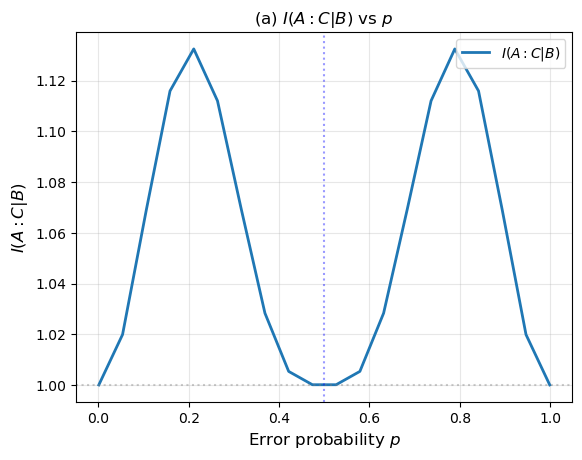

In [19]:
fig, ax = plt.subplots()

ax.plot(p_array, cmi_array,lw=2, label=r'$I(A{:}C|B)$')
#ax.plot(p_values, mi_AC_values, 'r--', lw=1.5, alpha=0.7, label=r'$I(A{:}C)$')
ax.axhline(1.0, color='gray', ls=':', alpha=0.4)
ax.axvline(0.5, color='blue', ls=':', alpha=0.4)
ax.set_xlabel(r'Error probability $p$', fontsize=12)
ax.set_ylabel(r'$I(A{:}C|B)$ ', fontsize=12)
ax.set_title(r'(a) $I(A{:}C|B)$ vs $p$', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.annotate(r'$p_c = 0.5$', xy=(0.5, 0.05), fontsize=10, color='blue',
            ha='center', va='bottom')

plt.show()

Comment: why CMI values might be a bit inflated, especially compared to the earloer results, calculated with H.

In [46]:
#check

rho_test = noise_channel(rho_GHZ, p_test, N)

print("Trace:", np.trace(rho_test))
print("Min eigenvalue:", np.min(np.linalg.eigvalsh(rho_test)))

Trace: 1.0000000000000002
Min eigenvalue: -3.0809129390480666e-17


In [47]:
print("Trace:", np.trace(rho_GHZ))
print("Min eigenvalue:", np.min(np.linalg.eigvalsh(rho_GHZ)))

Trace: 0.9999999999999998
Min eigenvalue: 0.0


In [25]:
#Array of different noise rates

p_array = np.linspace(0.001,0.999,40)
cmi_array = np.zeros(len(p_array))

for i in range(len(p_array)):
    cmi_array[i] = CMI(p_array[i],rho_GHZ,A=A,B=B,C=C,N=N)

S_AB=2.1604748425796445
S_BC=2.1604748425796445
S_B=2.0692958433614743
S_ABC=0.1368930732296651
CMI=2.1147607685681495
S_AB=4.452146163737348
S_BC=4.452146163737348
S_B=3.0662499923169735
S_ABC=2.1238804984599198
CMI=3.714161836697803
S_AB=6.025073940483649
S_BC=6.025073940483648
S_B=3.7504645163946426


KeyboardInterrupt: 